
Processing superblue1
read database from benchmark ../benchmarks/iccad2015/superblue1
node_net_num_max 29
node_area_max = 598040.181
Successfully saved graph and coordinates for superblue1.
max, min of coords: 0.9980873465538025, -0.9810070395469666
max, min of cond.x: 0.8246859908103943, 0.0010922992369160056


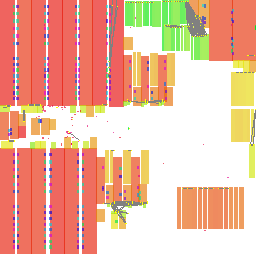

HPWL: 39.99916825807304

Processing superblue3
read database from benchmark ../benchmarks/iccad2015/superblue3
node_net_num_max 61
node_area_max = 1900314.108
Successfully saved graph and coordinates for superblue3.
max, min of coords: 0.9891422390937805, -0.975570023059845
max, min of cond.x: 0.7459283471107483, 0.00782717578113079


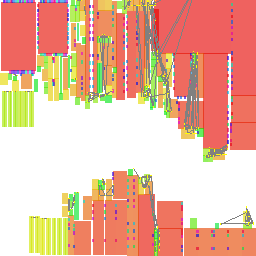

HPWL: 168.20559707091888

Processing superblue4
read database from benchmark ../benchmarks/iccad2015/superblue4
node_net_num_max 56
node_area_max = 1007384.9400000001
Successfully saved graph and coordinates for superblue4.
max, min of coords: 0.9913138151168823, -0.9723126888275146
max, min of cond.x: 0.9402822852134705, 0.0010857763700187206


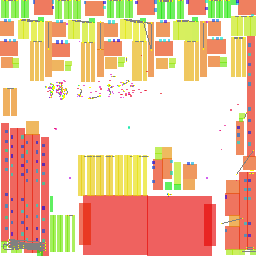

HPWL: 57.50833645107923

Processing superblue5
read database from benchmark ../benchmarks/iccad2015/superblue5
node_net_num_max 68
node_area_max = 2588790.2040000004
Successfully saved graph and coordinates for superblue5.
max, min of coords: 0.9928825497627258, -0.985161542892456
max, min of cond.x: 0.5654408931732178, 0.0077629080042243


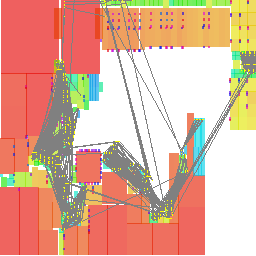

HPWL: 676.6656797264586

Processing superblue7
read database from benchmark ../benchmarks/iccad2015/superblue7
node_net_num_max 60
node_area_max = 2057318.784
Successfully saved graph and coordinates for superblue7.
max, min of coords: 0.9905213117599487, -0.9778783321380615
max, min of cond.x: 0.5852187275886536, 0.0006319115054793656


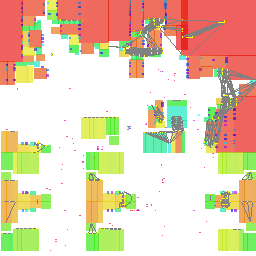

HPWL: 170.70993268791062

Processing superblue10
read database from benchmark ../benchmarks/iccad2015/superblue10
node_net_num_max 26
node_area_max = 1361642.2541999999
Successfully saved graph and coordinates for superblue10.
max, min of coords: 0.9954014420509338, -0.9918152689933777
max, min of cond.x: 0.4091787040233612, 0.009197093546390533


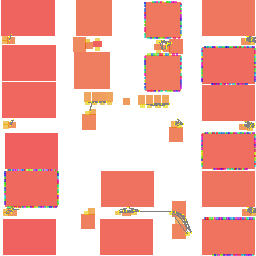

HPWL: 37.996339912118856

Processing superblue16
read database from benchmark ../benchmarks/iccad2015/superblue16
node_net_num_max 58
node_area_max = 252883.96559999997
Successfully saved graph and coordinates for superblue16.
max, min of coords: 0.9793295860290527, -0.9954836368560791
max, min of cond.x: 0.9620111584663391, 0.0011173184029757977


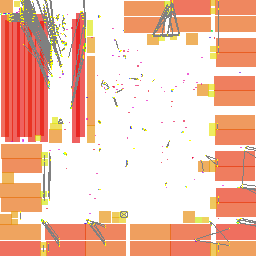

HPWL: 198.9473697548092

Processing superblue18
read database from benchmark ../benchmarks/iccad2015/superblue18
node_net_num_max 33
node_area_max = 820297.1232
Successfully saved graph and coordinates for superblue18.
max, min of coords: 0.9826233386993408, -0.9887892603874207
max, min of cond.x: 0.5762332081794739, 0.0011210762895643711


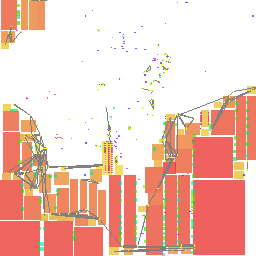

HPWL: 97.4640809338598

Summary of all benchmarks:
superblue1: HPWL=39.99916825807304
superblue3: HPWL=168.20559707091888
superblue4: HPWL=57.50833645107923
superblue5: HPWL=676.6656797264586
superblue7: HPWL=170.70993268791062
superblue10: HPWL=37.996339912118856
superblue16: HPWL=198.9473697548092
superblue18: HPWL=97.4640809338598


In [1]:
import os 
import sys  
sys.path.append("../")
sys.path.append("../flow_matching")
from benchmark_utils.iccad2015_utils import ProblemInstance
from flow_matching.utils import visualize_placement,hpwl_fast,hpwl
from PIL import Image
import pickle

# utils.visualize_placement(coords, cond)
# hpwl_fast(x, cond)
class Args:
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)

args = Args(BENCHMARK_DIR="../benchmarks/iccad2015",
            grid_soft_coeff=10,
            grid=224,
            n_macro=512)

benchmark_list = ["superblue1",
                  "superblue3", "superblue4", "superblue5", 
                  "superblue7", "superblue10", "superblue16", "superblue18"]


output_dir = "../datasets/graph/iccad2015-s0" # s for self-converted
os.makedirs(output_dir, exist_ok=True)
results = {}
problem_instances = {}

for idx, benchmark_name in enumerate(benchmark_list):
    print(f"\n{'='*50}")
    print(f"Processing {benchmark_name}")
    print(f"{'='*50}")
    
    # create problem instance and build graph
    problem_instance = ProblemInstance(args, benchmark_name)
    problem_instances[benchmark_name] = problem_instance

    coords, cond = problem_instance._build_pyg_data()
    cond.benchmark_name = benchmark_name
    cond_path = os.path.join(output_dir, f"graph{idx}.pickle")
    x_path = os.path.join(output_dir, f"output{idx}.pickle")

    with open(cond_path, 'wb') as f:
        pickle.dump(cond, f)
    with open(x_path, 'wb') as f:
        pickle.dump(coords, f)
    print(f"Successfully saved graph and coordinates for {benchmark_name}.")

    print(f"max, min of coords: {coords.max()}, {coords.min()}")
    print(f"max, min of cond.x: {cond.x.max()}, {cond.x.min()}")
    # visualize placement
    img = visualize_placement(coords, cond, True, True)
    Image.fromarray(img).show()
    
    # calculate HPWL
    hpwl_result = hpwl(coords, cond)

    # save results
    results[benchmark_name] = {
        'hpwl': hpwl_result,
    }
    
    print(f"HPWL: {hpwl_result}")

# print summary of all benchmarks
print(f"\n{'='*50}")
print("Summary of all benchmarks:")
print(f"{'='*50}")
for benchmark_name, metrics in results.items():
    print(f"{benchmark_name}: HPWL={metrics['hpwl']}")



In [2]:
config_file = """
# Copy this into the benchmark directory
train_samples: 0
val_samples: 8 # change this to the number of circuits in benchmark (18 for ibm, 8 for ispd)
scale: 1
chip_width: 2.0
chip_height: 2.0
preprocessed: true
"""
with open(os.path.join(output_dir, "config.yaml"), 'w') as f:
    f.write(config_file)

In [3]:
from benchmark_utils.iccad2015_utils import get_inv_scaling_ratio
for benchmark_name in benchmark_list:
    problem_instance = problem_instances[benchmark_name]
    inv_scaling_ratio = get_inv_scaling_ratio(problem_instance.database)
    print(f"{benchmark_name}: inv_scaling_ratio = {inv_scaling_ratio}")

superblue1: inv_scaling_ratio = (2000.0, 1999.9999999999998)
superblue3: inv_scaling_ratio = (2000.0, 2000.0)
superblue4: inv_scaling_ratio = (2000.0, 2000.0)
superblue5: inv_scaling_ratio = (2000.0, 2000.0)
superblue7: inv_scaling_ratio = (2000.0, 2000.0000000000002)
superblue10: inv_scaling_ratio = (2000.0, 2000.0000000000002)
superblue16: inv_scaling_ratio = (2000.0000000000002, 2000.0)
superblue18: inv_scaling_ratio = (1999.9999999999998, 2000.0)
